# Phase 2.2 - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to understand the PJM Hourly Energy Consumption dataset before feature engineering and model building.

This notebook includes:

- Dataset Overview
- Missing Value Analysis
- Duplicate Analysis
- Time Series Visualization
- Distribution Analysis
- Trend Analysis
- Seasonality Analysis
- Stationarity Tests
- Correlation Analysis
- Outlier Detection
- Data Quality Report

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)
pd.set_option("display.width",150)

In [6]:
DATA_PATH = Path("../data/raw/PJME_hourly.csv")

df = pd.read_csv(DATA_PATH)

df["Datetime"] = pd.to_datetime(df["Datetime"])

df.set_index("Datetime", inplace=True)

print(df.head())

                     PJME_MW
Datetime                    
2002-12-31 01:00:00  26498.0
2002-12-31 02:00:00  25147.0
2002-12-31 03:00:00  24574.0
2002-12-31 04:00:00  24393.0
2002-12-31 05:00:00  24860.0


In [7]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 145366
Columns : 1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PJME_MW,145366.0,32080.222831,6464.012166,14544.0,27573.0,31421.0,35650.0,62009.0


In [10]:
df.isnull().sum()

PJME_MW    0
dtype: int64

In [11]:
print(df.duplicated().sum())
print(df.index.duplicated().sum())

116925
4


In [12]:
print(df.index.min())

print(df.index.max())

2002-01-01 01:00:00
2018-08-03 00:00:00


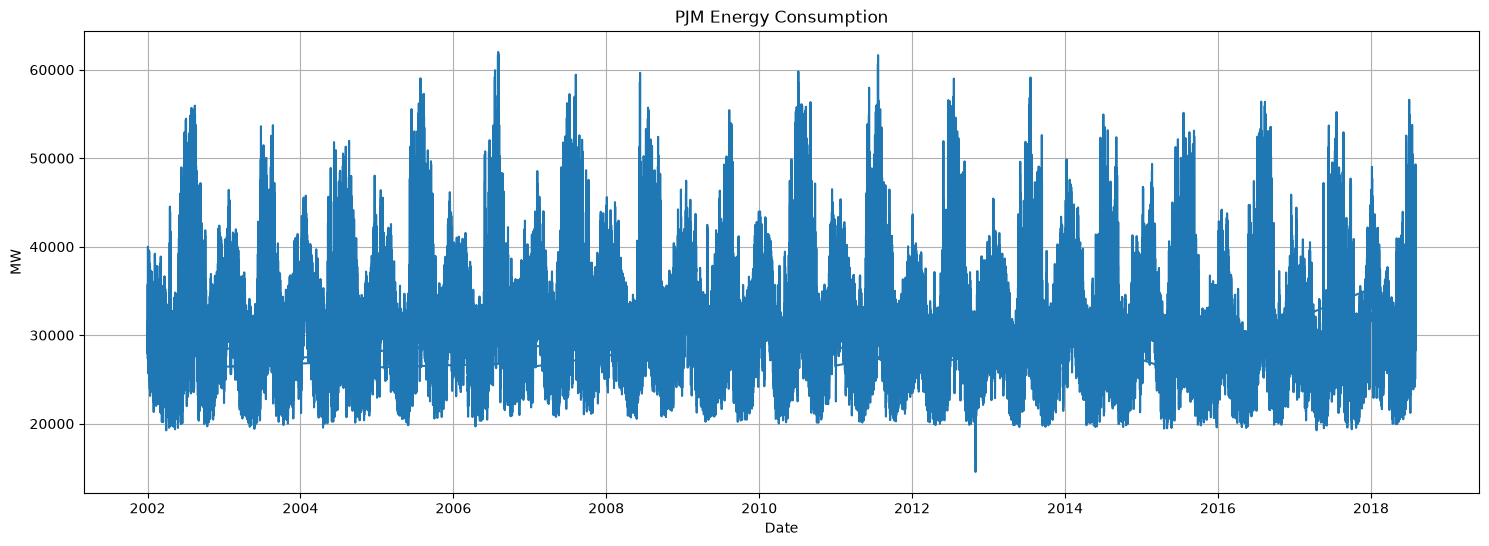

In [13]:
plt.figure(figsize=(18,6))

plt.plot(df.index,df["PJME_MW"])

plt.title("PJM Energy Consumption")

plt.xlabel("Date")

plt.ylabel("MW")

plt.grid(True)

plt.show()

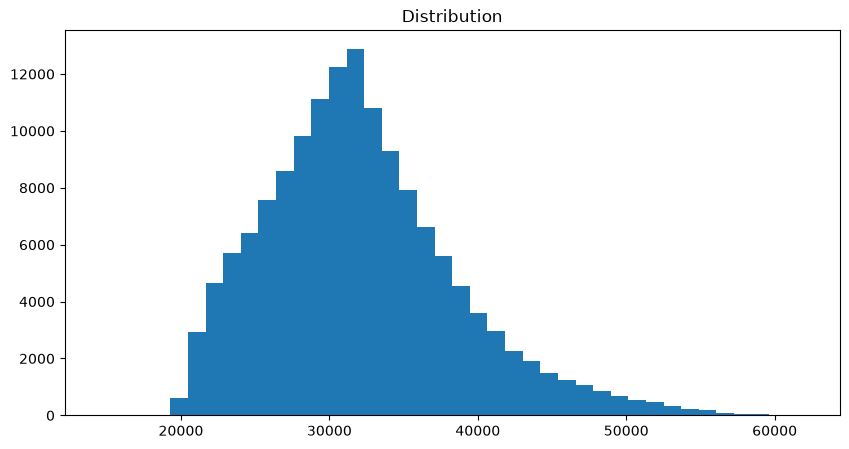

In [14]:
plt.figure(figsize=(10,5))

plt.hist(df["PJME_MW"],bins=40)

plt.title("Distribution")

plt.show()

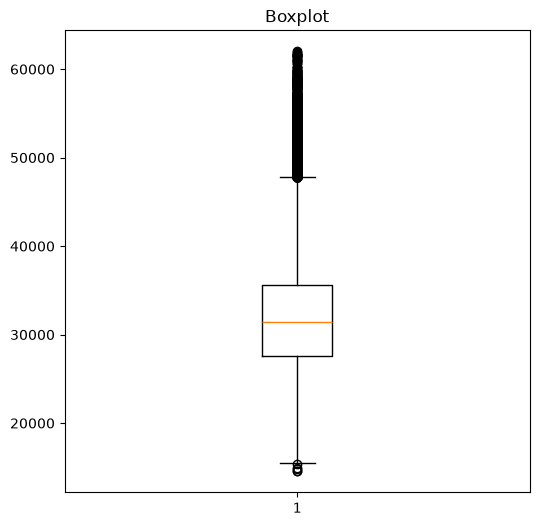

In [15]:
plt.figure(figsize=(6,6))

plt.boxplot(df["PJME_MW"])

plt.title("Boxplot")

plt.show()

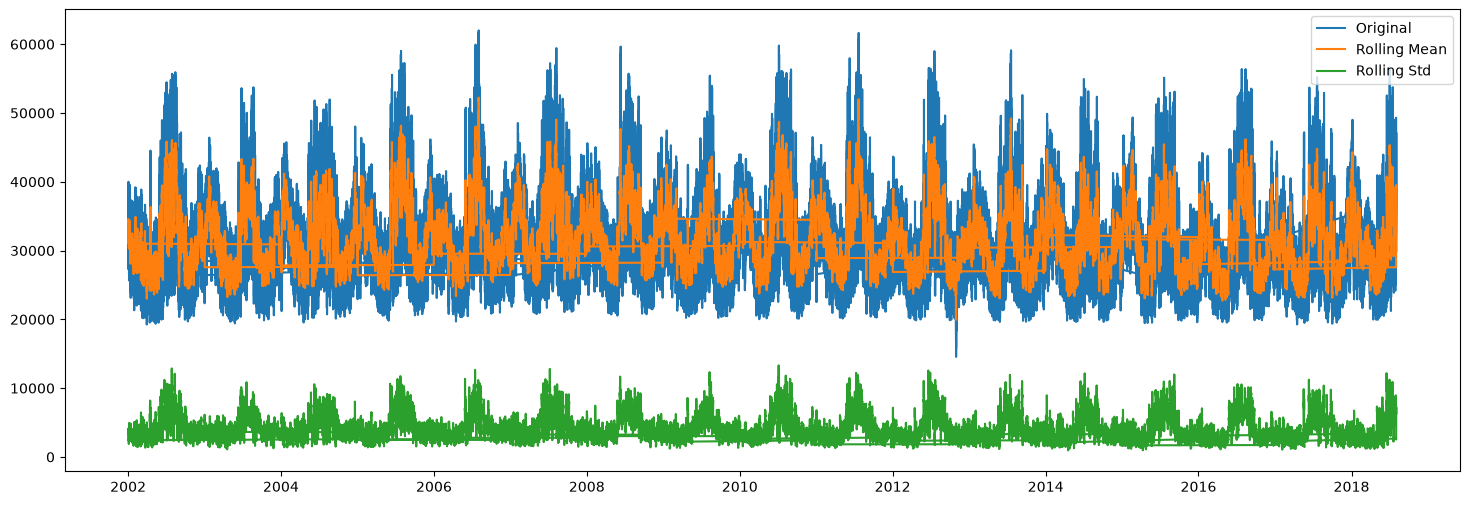

In [16]:
rolling_mean=df["PJME_MW"].rolling(24).mean()

rolling_std=df["PJME_MW"].rolling(24).std()

plt.figure(figsize=(18,6))

plt.plot(df["PJME_MW"],label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.show()

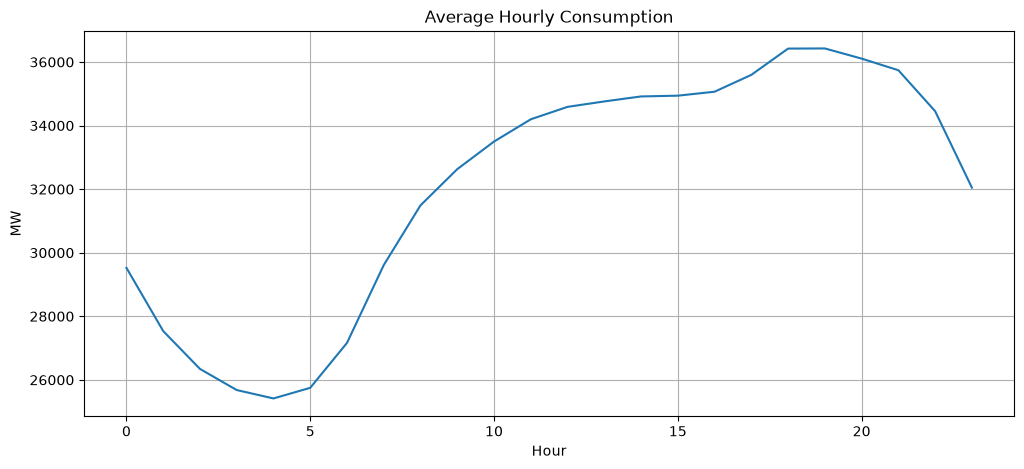

In [17]:
hourly=df.groupby(df.index.hour)["PJME_MW"].mean()

plt.figure(figsize=(12,5))

plt.plot(hourly)

plt.title("Average Hourly Consumption")

plt.xlabel("Hour")

plt.ylabel("MW")

plt.grid(True)

plt.show()

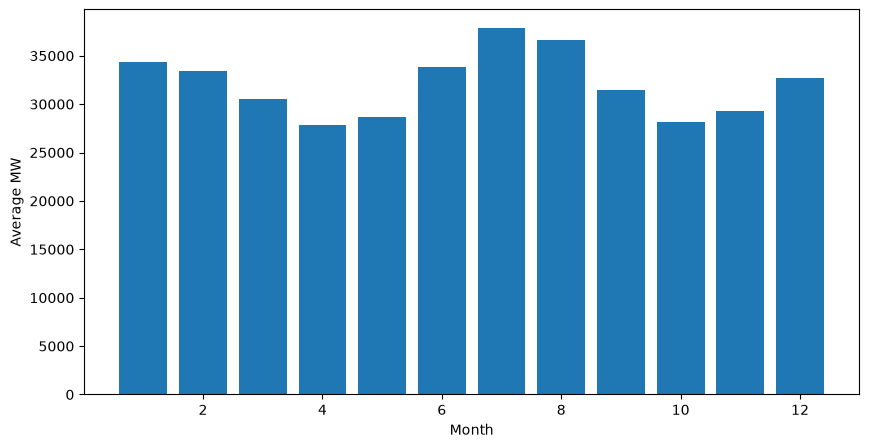

In [18]:
monthly=df.groupby(df.index.month)["PJME_MW"].mean()

plt.figure(figsize=(10,5))

plt.bar(monthly.index,monthly.values)

plt.xlabel("Month")

plt.ylabel("Average MW")

plt.show()

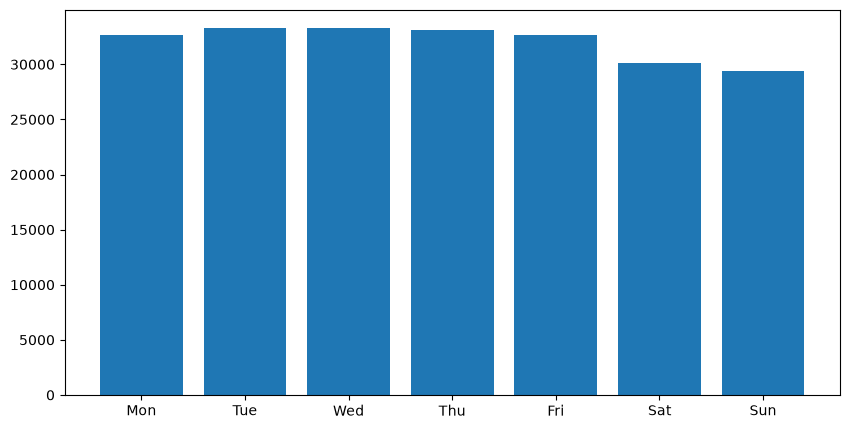

In [19]:
weekday=df.groupby(df.index.dayofweek)["PJME_MW"].mean()

plt.figure(figsize=(10,5))

plt.bar(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
    weekday.values
)

plt.show()

In [27]:
from statsmodels.tsa.stattools import adfuller, kpss

print("=" * 70)
print("        STATIONARITY TESTS")
print("=" * 70)

# -------------------- ADF TEST --------------------
adf_result = adfuller(df["PJME_MW"])

print("\n1. Augmented Dickey-Fuller (ADF) Test")
print("-" * 50)
print(f"ADF Statistic : {adf_result[0]:.6f}")
print(f"p-value       : {adf_result[1]:.6f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.6f}")

if adf_result[1] < 0.05:
    adf_stationary = True
    print("\nADF Conclusion: ✅ Stationary")
else:
    adf_stationary = False
    print("\nADF Conclusion: ❌ Non-Stationary")


# -------------------- KPSS TEST --------------------
print("\n" + "=" * 70)

kpss_result = kpss(df["PJME_MW"], regression="c", nlags="auto")

print("\n2. KPSS Test")
print("-" * 50)
print(f"KPSS Statistic : {kpss_result[0]:.6f}")
print(f"p-value        : {kpss_result[1]:.6f}")
print(f"Lags Used      : {kpss_result[2]}")

print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.6f}")

if kpss_result[1] > 0.05:
    kpss_stationary = True
    print("\nKPSS Conclusion: ✅ Stationary")
else:
    kpss_stationary = False
    print("\nKPSS Conclusion: ❌ Non-Stationary")


# -------------------- FINAL INTERPRETATION --------------------
print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)

if adf_stationary and kpss_stationary:
    print("✅ The time series is STATIONARY.")
    print("Both ADF and KPSS tests support stationarity.")

elif (not adf_stationary) and (not kpss_stationary):
    print("❌ The time series is NON-STATIONARY.")
    print("Both ADF and KPSS tests support non-stationarity.")

elif adf_stationary and (not kpss_stationary):
    print("⚠️ Mixed Results")
    print("ADF indicates Stationary, but KPSS indicates Non-Stationary.")
    print("This usually suggests the series is trend-stationary.")
    print("Consider detrending before modeling.")

else:
    print("⚠️ Mixed Results")
    print("ADF indicates Non-Stationary, but KPSS indicates Stationary.")
    print("Further investigation is recommended (ACF/PACF, decomposition, differencing).")

        STATIONARITY TESTS

1. Augmented Dickey-Fuller (ADF) Test
--------------------------------------------------
ADF Statistic : -18.828913
p-value       : 0.000000
Lags Used     : 74
Observations  : 145291

Critical Values:
   1%: -3.430395
   5%: -2.861560
   10%: -2.566781

ADF Conclusion: ✅ Stationary


2. KPSS Test
--------------------------------------------------
KPSS Statistic : 1.176234
p-value        : 0.010000
Lags Used      : 162

Critical Values:
   10%: 0.347000
   5%: 0.463000
   2.5%: 0.574000
   1%: 0.739000

KPSS Conclusion: ❌ Non-Stationary

FINAL INTERPRETATION
⚠️ Mixed Results
ADF indicates Stationary, but KPSS indicates Non-Stationary.
This usually suggests the series is trend-stationary.
Consider detrending before modeling.


Daily (24 Hours) Seasonal Decomposition


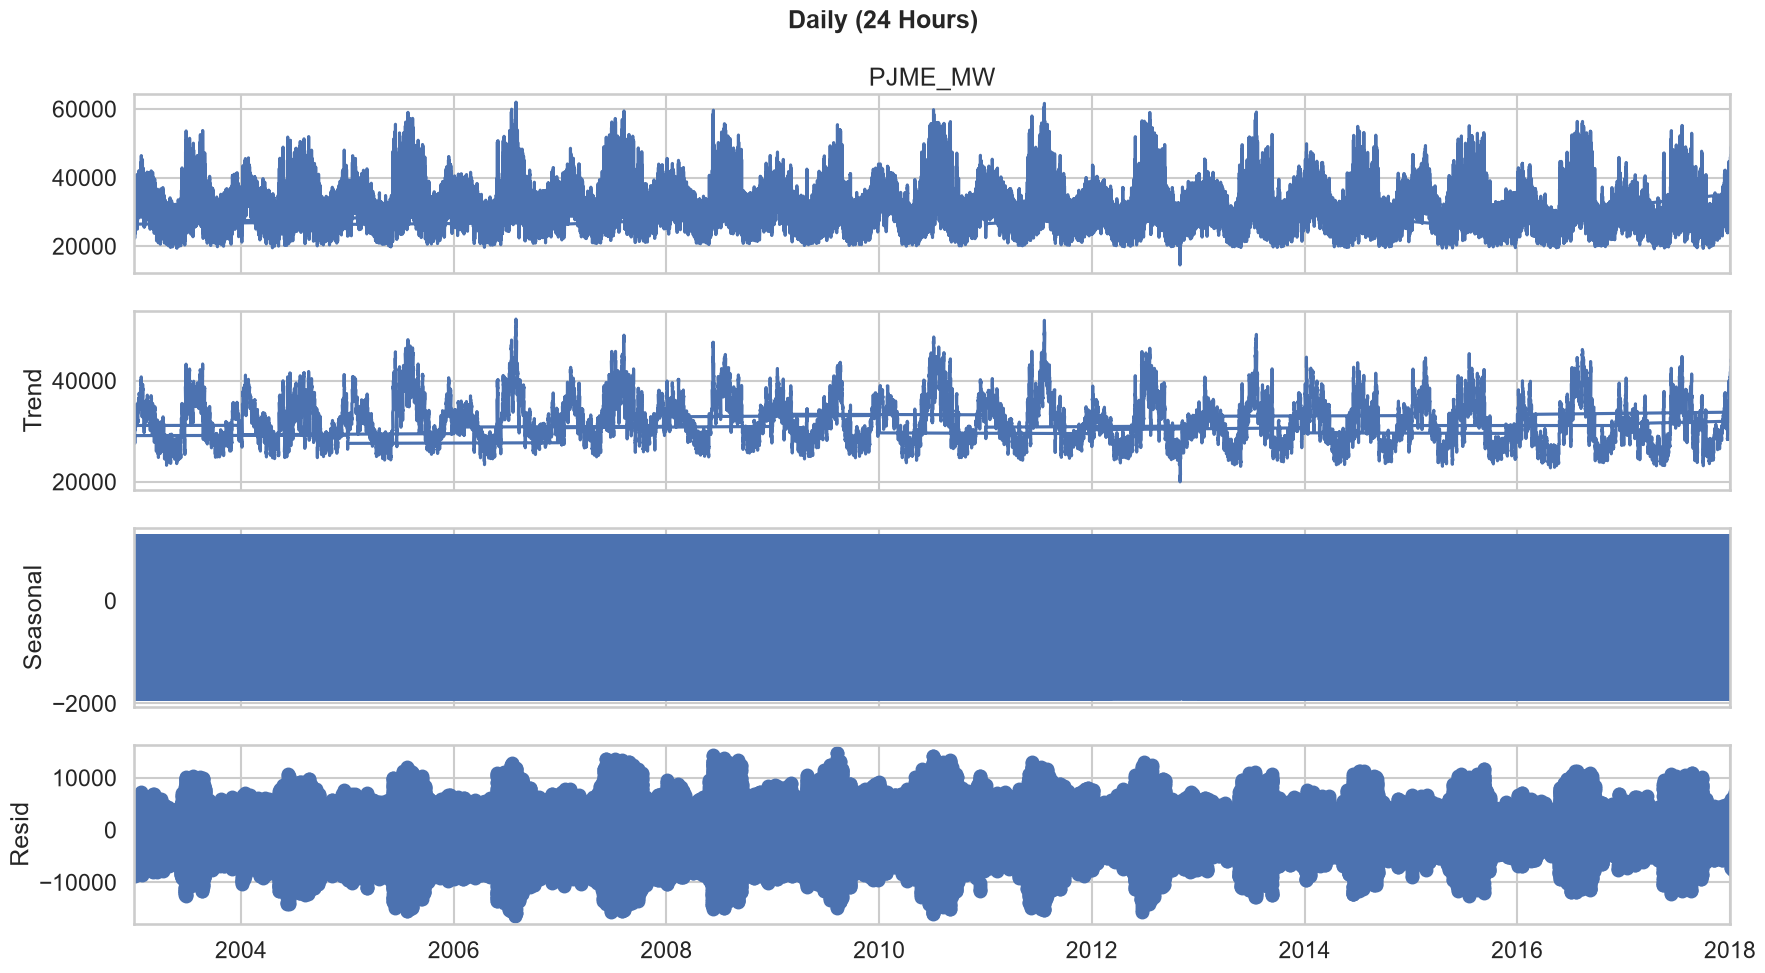

Weekly (168 Hours) Seasonal Decomposition


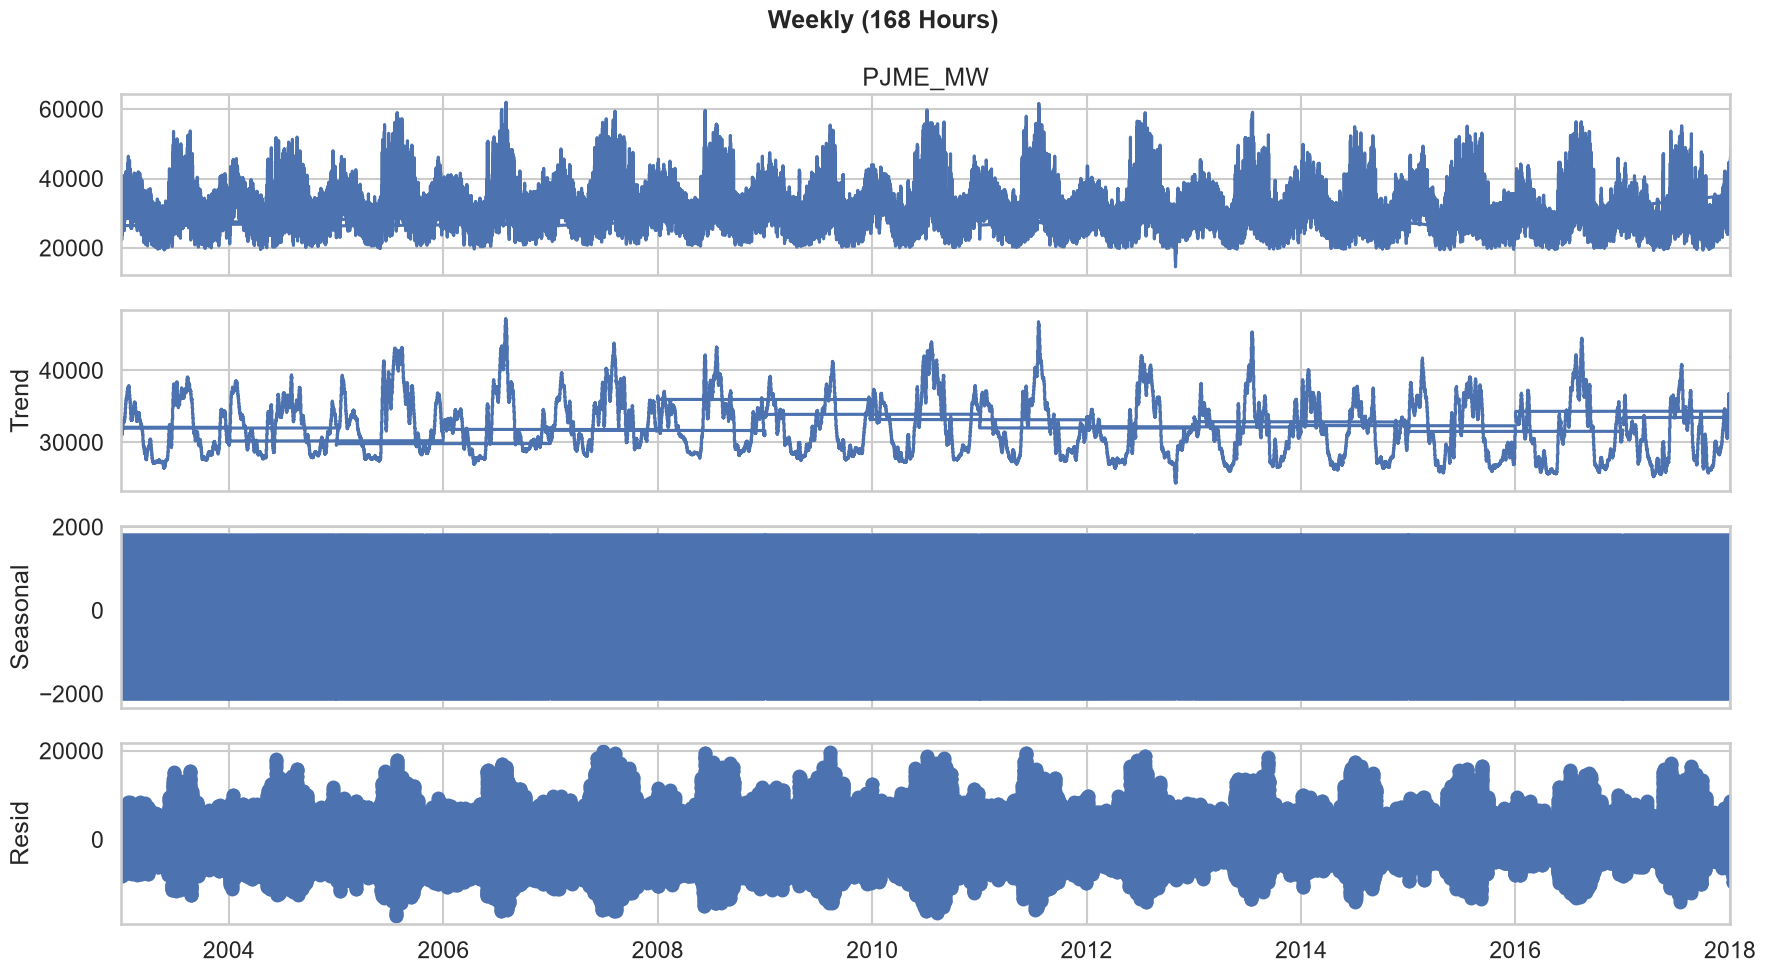

Monthly (720 Hours Approx.) Seasonal Decomposition


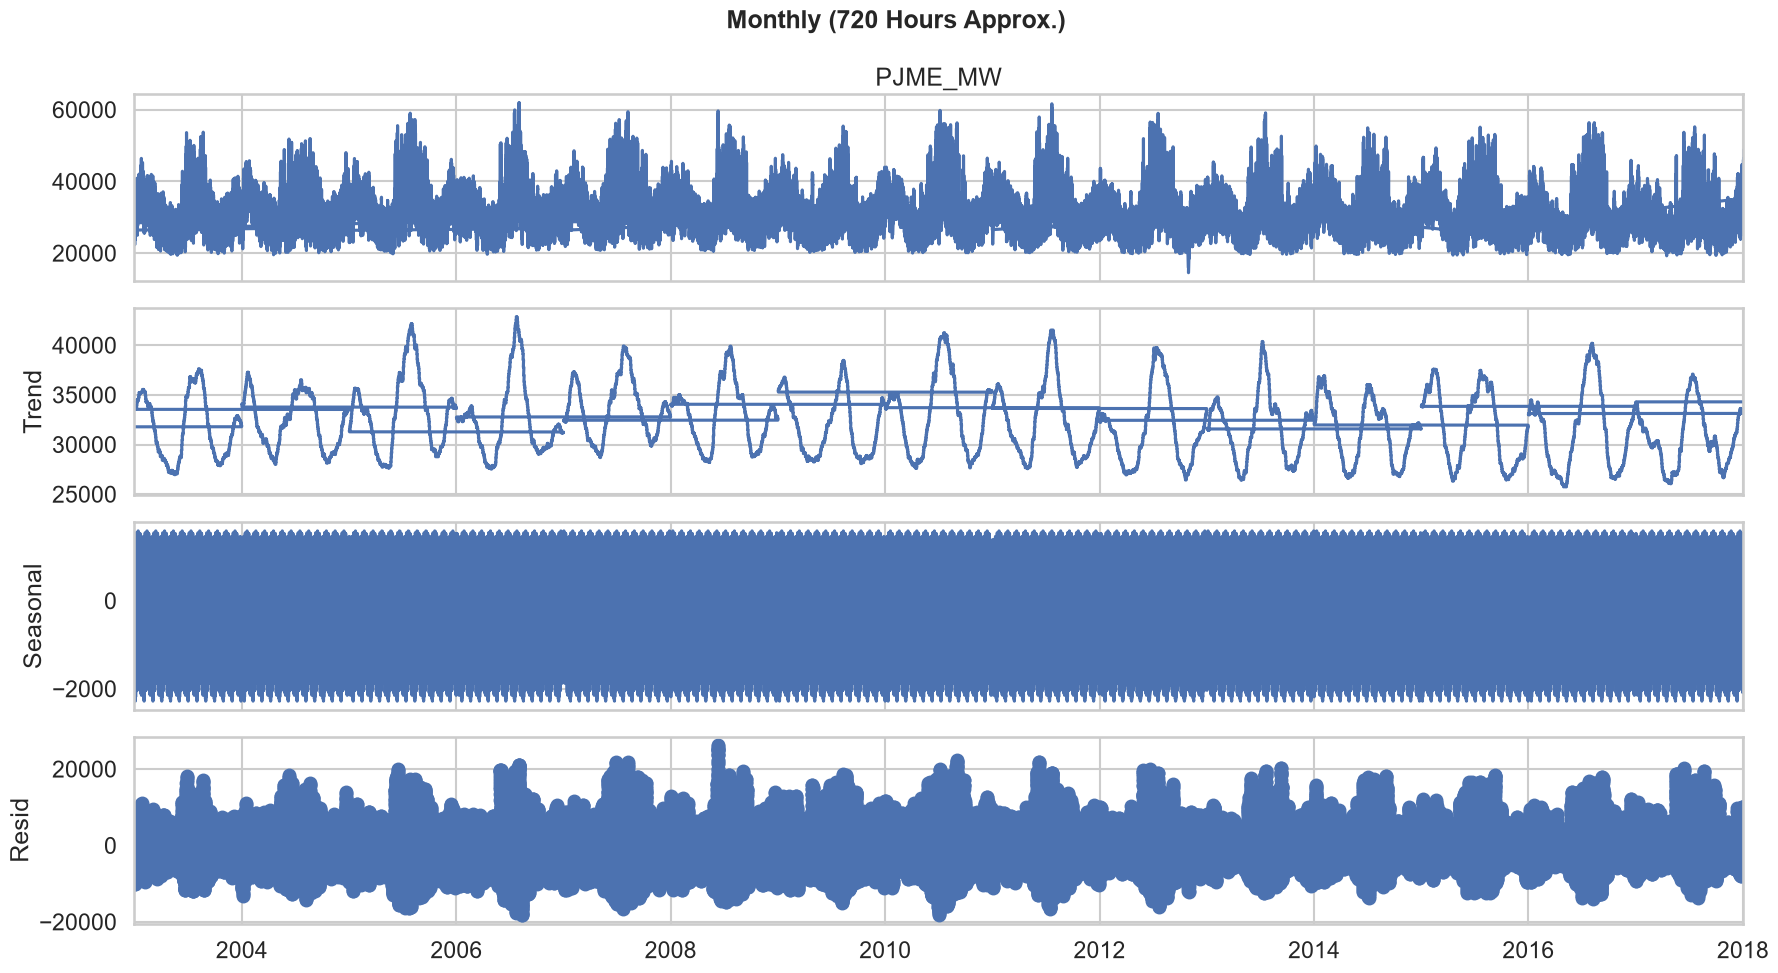

In [28]:
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Seaborn styling
sns.set_theme(style="whitegrid", context="talk")

# Different seasonal periods
periods = {
    "Daily (24 Hours)": 24,
    "Weekly (168 Hours)": 24 * 7,
    "Monthly (720 Hours Approx.)": 24 * 30
}

for title, period in periods.items():

    print("=" * 80)
    print(f"{title} Seasonal Decomposition")
    print("=" * 80)

    decomposition = seasonal_decompose(
        df["PJME_MW"],
        model="additive",
        period=period
    )

    fig = decomposition.plot()
    fig.set_size_inches(18, 10)

    plt.suptitle(title, fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()

<Figure size 1200x500 with 0 Axes>

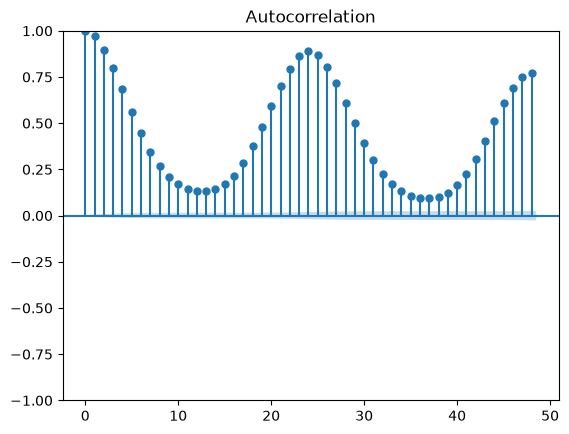

In [22]:
plt.figure(figsize=(12,5))

plot_acf(df["PJME_MW"],lags=48)

plt.show()

<Figure size 1200x500 with 0 Axes>

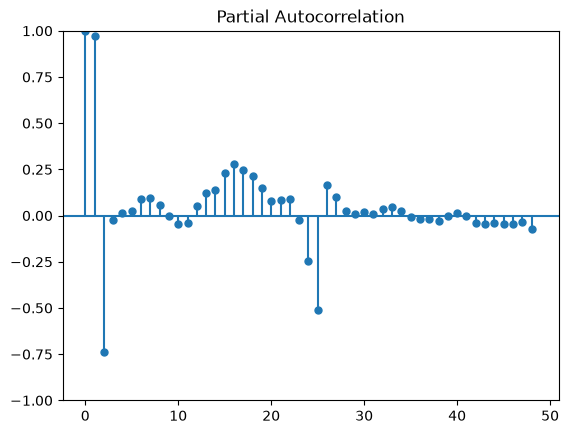

In [23]:
plt.figure(figsize=(12,5))

plot_pacf(df["PJME_MW"],lags=48)

plt.show()

In [24]:
z=np.abs(stats.zscore(df["PJME_MW"]))

outliers=df[z>3]

print("Outliers :",len(outliers))

Outliers : 1318


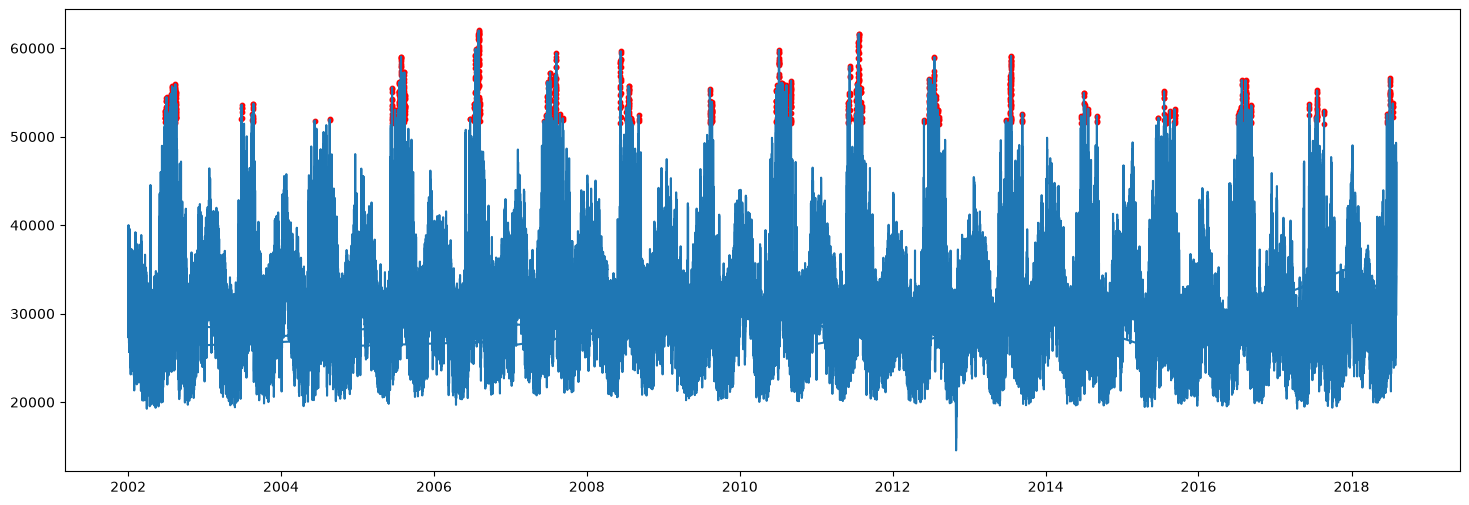

In [25]:
plt.figure(figsize=(18,6))

plt.plot(df.index,df["PJME_MW"])

plt.scatter(outliers.index,
            outliers["PJME_MW"],
            color="red",
            s=10)

plt.show()

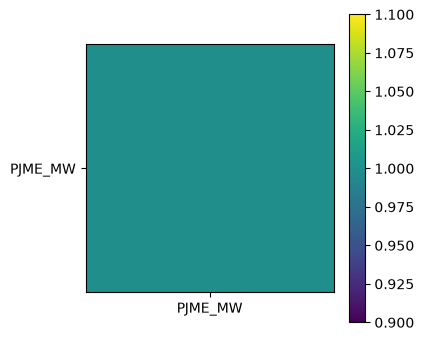

In [26]:
corr=df.corr()

plt.figure(figsize=(4,4))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.show()